Anfang "data_cleaning" Notebook

Packages importieren

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np 
import scipy as stats

Daten laden

In [16]:
df = pd.read_csv("../data/dataset.csv")

# These codes mean "unknown / not applicable" — treat them as missing
MISSING_CODES = [97, 98, 99]

# Columns that use the 1/2/97/98/99 coding (everything except AGE and DATE_DIED)
binary_cols = [
    "INTUBED", "PNEUMONIA", "PREGNANT", "DIABETES", "COPD", "ASTHMA",
    "INMSUPR", "HIPERTENSION", "OTHER_DISEASE", "CARDIOVASCULAR",
    "OBESITY", "RENAL_CHRONIC", "TOBACCO", "ICU"
]

# Replace 97/98/99 with NaN so Python treats them as missing
for col in binary_cols:
    df[col] = df[col].replace(MISSING_CODES, np.nan)

# Create a proper "died" binary column from DATE_DIED
df["DIED"] = (df["DATE_DIED"] != "9999-99-99").astype(int)

print(df.shape)
df.head()

(1048575, 22)


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,DIED
0,2,1,1,1,3/5/20,NaN,1.0,65.0,2.0,2.0,...,2.0,1.0,2.0,2.0,2.0,2.0,2.0,3,NaN,1
1,2,1,2,1,3/6/20,NaN,1.0,72.0,NaN,2.0,...,2.0,1.0,2.0,2.0,1.0,1.0,2.0,5,NaN,1
2,2,1,2,2,9/6/20,1.0,2.0,55.0,NaN,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,2.0,1
3,2,1,1,1,12/6/20,NaN,2.0,NaN,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,7,NaN,1
4,2,1,2,1,21/06/2020,NaN,2.0,NaN,NaN,1.0,...,2.0,1.0,2.0,2.0,2.0,2.0,2.0,3,NaN,1


In [17]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(1)
}).sort_values("missing_pct", ascending=False)

print(missing[missing["missing_count"] > 0])

                missing_count  missing_pct
ICU                    856032         81.6
INTUBED                855868         81.6
PREGNANT               527265         50.3
PNEUMONIA               16003          1.5
OTHER_DISEASE            5045          0.5
ASTHMA                   2979          0.3
CARDIOVASCULAR           3077          0.3
TOBACCO                  3221          0.3
RENAL_CHRONIC            3006          0.3
DIABETES                 3339          0.3
COPD                     3003          0.3
OBESITY                  3032          0.3
INMSUPR                  3405          0.3
HIPERTENSION             3104          0.3
AGE                         6          0.0


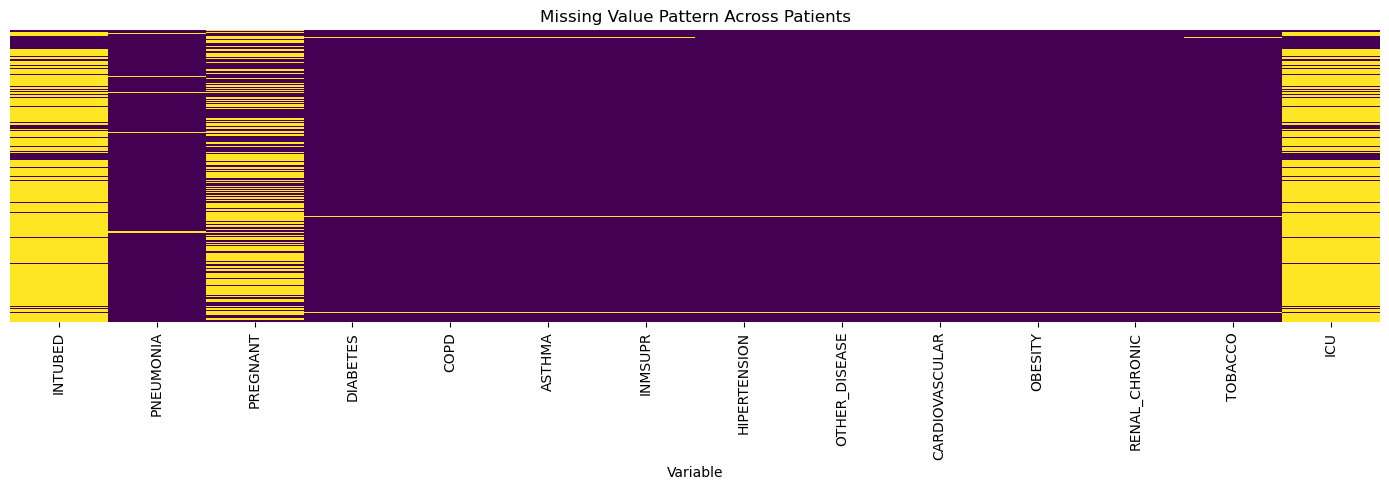

In [ ]:
#Heatmap with Missing Values
plt.figure(figsize=(14, 5))
sns.heatmap(df[binary_cols].isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Pattern Across Patients")
plt.xlabel("Variable")
plt.tight_layout()
plt.show()

In [20]:
# impute with mode (because binary column) -> if 80% of data missing & all replaced with number that already exists more, changes a lot???? 
for col in binary_cols:
    if df[col].isnull().any():
        df[f"{col}_was_missing"] = df[col].isnull().astype(int)
        df[col] = df[col].fillna(df[col].mode()[0])

# AGE: impute with median
if df["AGE"].isnull().any():
    df["AGE_was_missing"] = df["AGE"].isnull().astype(int)
    df["AGE"] = df["AGE"].fillna(df["AGE"].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


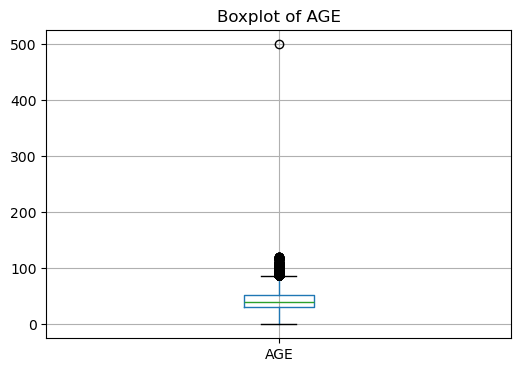

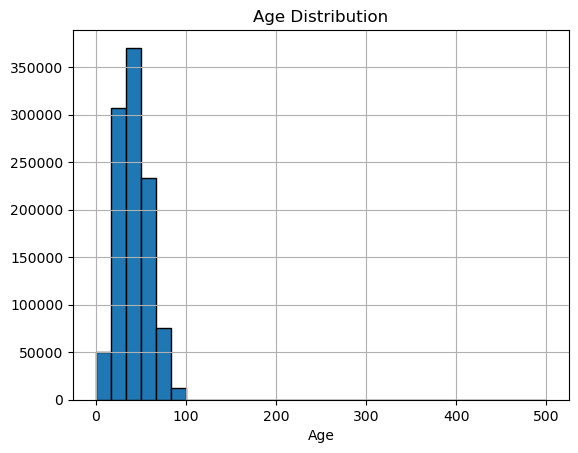

Age outliers (IQR rule): 5641 rows
count    5641.000000
mean       91.630207
std         6.669139
min        88.000000
25%        89.000000
50%        90.000000
75%        93.000000
max       500.000000
Name: AGE, dtype: float64


In [ ]:
# Boxplot
plt.figure(figsize=(6, 4))
df.boxplot(column="AGE")
plt.title("Boxplot of AGE")
plt.show()

# Histogram
df["AGE"].hist(bins=30, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

# IQR
Q1, Q3 = df["AGE"].quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df["AGE"] < low) | (df["AGE"] > high)]
print(f"Age outliers (IQR rule): {len(outliers)} rows")
print(outliers["AGE"].describe())